In [23]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import random

sns.set_theme(style="whitegrid")

In [24]:
dataset_path = 'apple_dataset' 

data = []
splits = ['train', 'val', 'test']

for split in splits:
    split_path = os.path.join(dataset_path, split)
    if not os.path.exists(split_path):
        continue
        
    classes = os.listdir(split_path)
    for class_name in classes:
        class_path = os.path.join(split_path, class_name)
        if os.path.isdir(class_path):
            num_images = len(glob.glob(os.path.join(class_path, '*.*')))
            data.append({'Split': split, 'Classe': class_name, 'Nombre d images': num_images})

df_counts = pd.DataFrame(data)

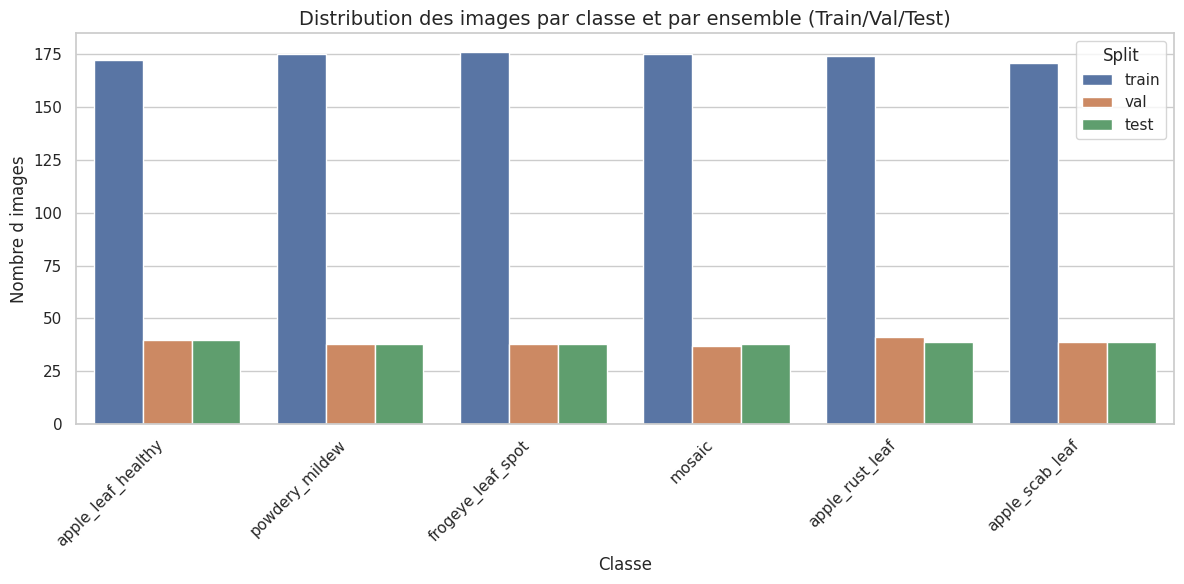

In [25]:
plt.figure(figsize=(12, 6))
sns.barplot(data=df_counts, x='Classe', y='Nombre d images', hue='Split')
plt.title('Distribution des images par classe et par ensemble (Train/Val/Test)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

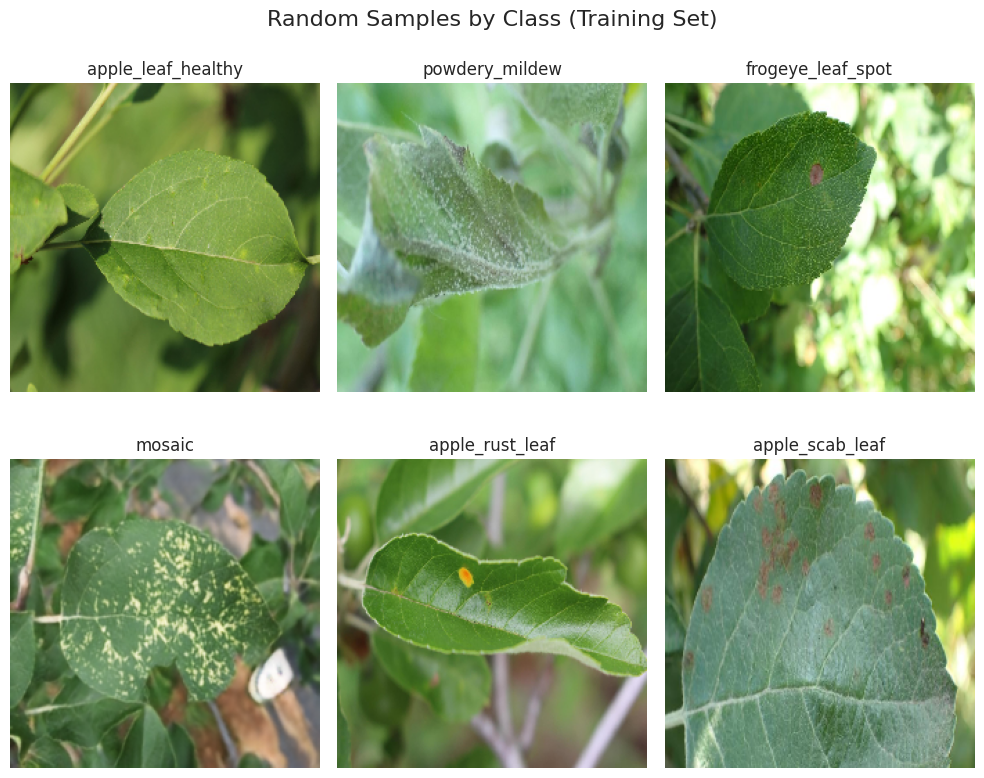

In [22]:
train_path = os.path.join(dataset_path, 'train')
classes = [d for d in os.listdir(train_path) if os.path.isdir(os.path.join(train_path, d))]

plt.figure(figsize=(10, 8))
for i, class_name in enumerate(classes):
    class_dir = os.path.join(train_path, class_name)
    images = glob.glob(os.path.join(class_dir, '*.*'))
    
    if images:
        random_image_path = random.choice(images)
        img = cv2.imread(random_image_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (224, 224))
        
        plt.subplot(2, 3, i + 1)
        plt.imshow(img)
        plt.title(class_name)
        plt.axis('off')

plt.tight_layout()
plt.suptitle('Random Samples by Class (Training Set)', fontsize=16, y=1.02)
plt.show()